# Open CV course

## Import necessary libraries

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(1, '')
import utility as util

# Without this, no need to use plt.show()
%matplotlib inline

## Load image mode color (default)

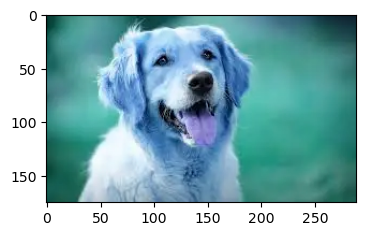

In [8]:
img = cv2.imread('images.jpg', cv2.IMREAD_COLOR)
util.image_show(img)

Since default image format is RGB but in cv2, it consider image as BGR, we need a convert

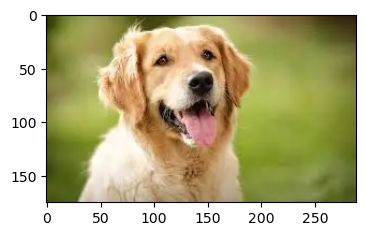

In [9]:
# Everyone way
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
# Without library (hard to read)
# img = img[:, :, ::-1]

util.image_show(img)

## Basic Manipulating

Split image

Text(0.5, 1.0, 'Origin')

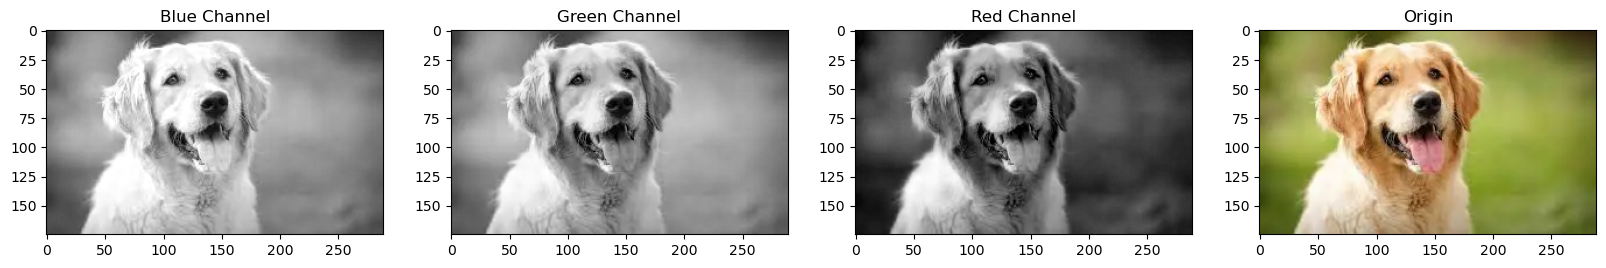

In [18]:
b, g, r = cv2.split(img)
plt.figure(figsize=(20, 5))
plt.subplot(141);plt.imshow(b, cmap='gray');plt.title('Blue Channel')
plt.subplot(142);plt.imshow(g, cmap='gray');plt.title('Green Channel')
plt.subplot(143);plt.imshow(r, cmap='gray');plt.title('Red Channel')
plt.subplot(144);plt.imshow(cv2.merge([b, g, r]));plt.title('Origin')
plt.show()

Convert color image to grayscale, crop

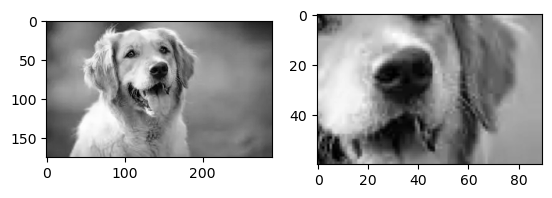

In [28]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
crop = gray_img[40:100, 110:200]
plt.subplot(121);plt.imshow(gray_img, cmap='gray')
plt.subplot(122);plt.imshow(crop, cmap='gray')
plt.show()

we can modify some pixel

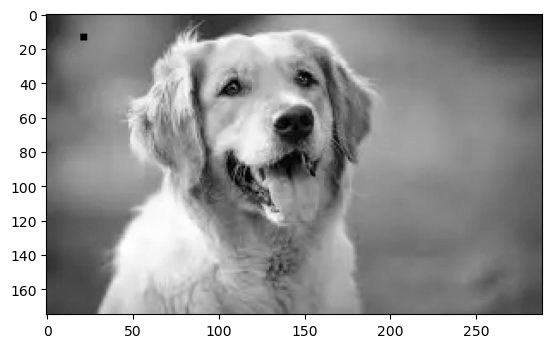

In [31]:
gray_img[12:16, 20:24] = 0
plt.imshow(gray_img, cmap='gray')
plt.show()

Resize

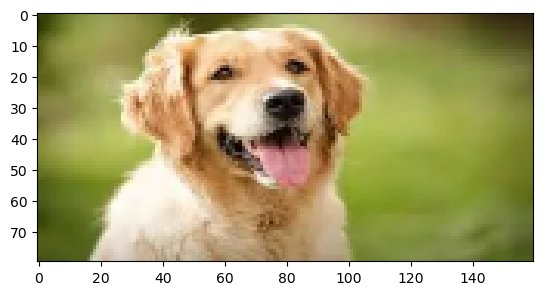

In [41]:
resize_img = cv2.resize(img, (160, 80))
plt.imshow(resize_img)
plt.show()

Flip

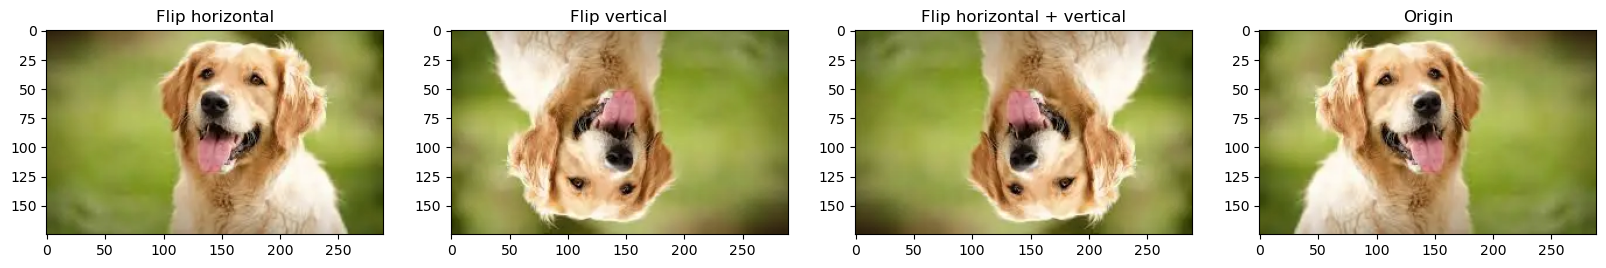

In [45]:
flip_hor_img = cv2.flip(img, 1)
flip_ver_img = cv2.flip(img, 0)
flip_hor_ver_img = cv2.flip(img, -1)

plt.figure(figsize=(20, 5))
plt.subplot(141);plt.imshow(flip_hor_img);plt.title('Flip horizontal')
plt.subplot(142);plt.imshow(flip_ver_img);plt.title('Flip vertical')
plt.subplot(143);plt.imshow(flip_hor_ver_img);plt.title('Flip horizontal + vertical')
plt.subplot(144);plt.imshow(img);plt.title('Origin')
plt.show()

## Image Annotation

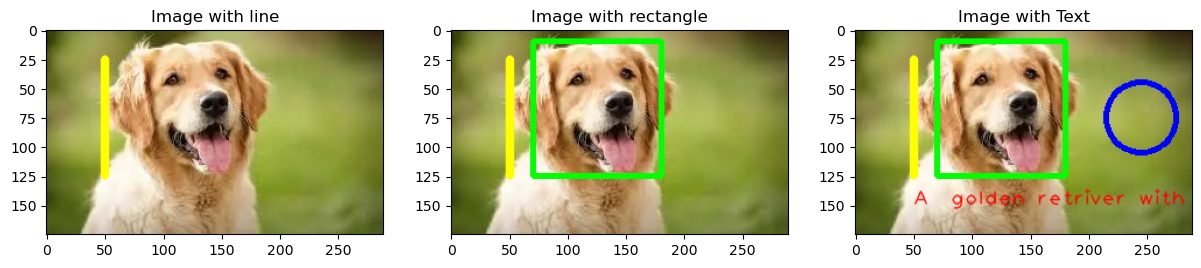

In [15]:
img_line = cv2.line(img.copy(), (50, 25), (50, 125), (255, 255, 0), thickness=5, lineType=cv2.LINE_AA)
img_rectangle = cv2.rectangle(img_line.copy(), (70, 10), (180, 125), (0, 255, 0), thickness=3, lineType=cv2.LINE_4)
img_circle = cv2.circle(img_rectangle.copy(), (245, 75), 30, (0, 0, 255), thickness=4,lineType=cv2.LINE_8)

text = 'A  golden retriver with a happy face looking at the camera'
img_text = cv2.putText(img_circle.copy(), text, (50, 150), cv2.FONT_HERSHEY_PLAIN, 1.2, (255, 0, 0), 1, cv2.LINE_AA)

plt.figure(figsize=(20, 5))
plt.subplot(141);plt.imshow(img_line);plt.title('Image with line')
plt.subplot(142);plt.imshow(img_rectangle);plt.title('Image with rectangle')
plt.subplot(143);plt.imshow(img_circle);plt.title('Image with circle')
plt.subplot(143);plt.imshow(img_text);plt.title('Image with Text')
plt.show()

## Image Enhancement

Addition or Brightness

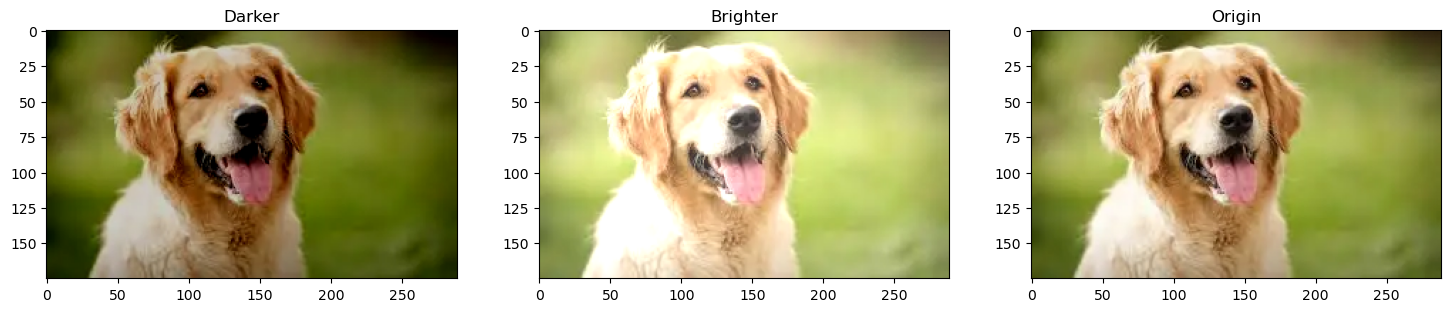

In [17]:
matrix = np.ones(img.shape, dtype='uint8') * 50

img_brighter = cv2.add(img, matrix)
img_darker = cv2.subtract(img, matrix)

plt.figure(figsize=(18, 6))
plt.subplot(131);plt.imshow(img_darker);plt.title('Darker')
plt.subplot(132);plt.imshow(img_brighter);plt.title('Brighter')
plt.subplot(133);plt.imshow(img);plt.title('Origin')
plt.show()

Multiplication or Contrast

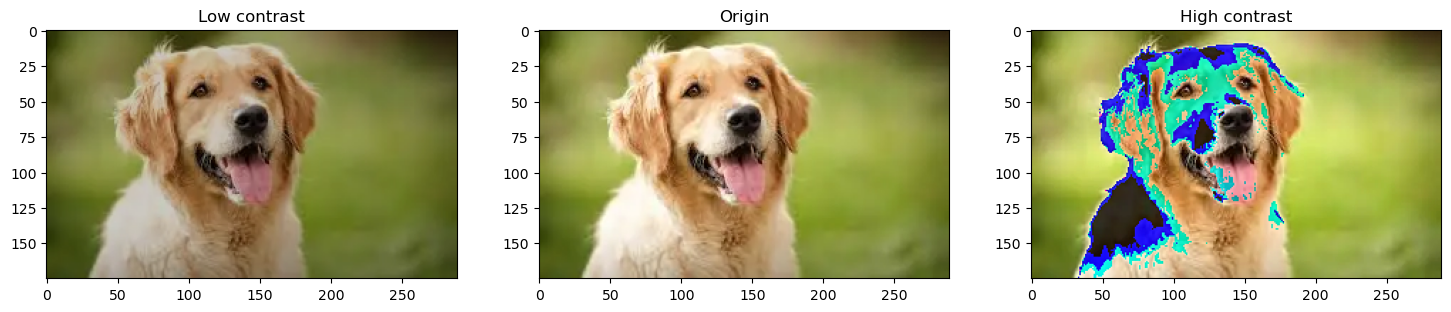

In [21]:
matrix1 = np.ones(img.shape) * 0.8
matrix2 = np.ones(img.shape) * 1.2

img_low_contrast = np.uint8(cv2.multiply(np.float64(img), matrix1))
img_high_contrast = np.uint8(cv2.multiply(np.float64(img), matrix2))

plt.figure(figsize=(18, 6))
plt.subplot(131);plt.imshow(img_low_contrast);plt.title('Low contrast')
plt.subplot(132);plt.imshow(img);plt.title('Origin')
plt.subplot(133);plt.imshow(img_high_contrast);plt.title('High contrast')
plt.show()

since cv2.multiply make the color value >255 become >0 (Thanks to cv2, why don't they auto clip it like add function?)
we literally clip to avoid over value

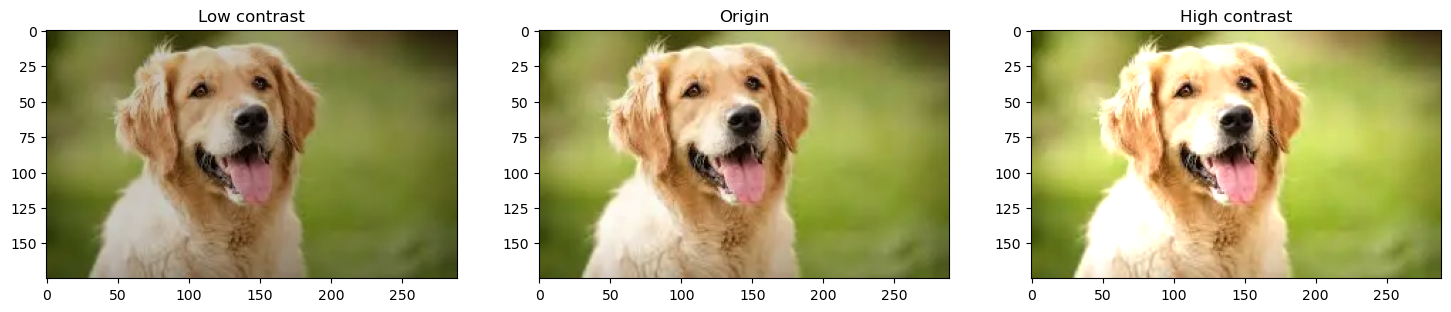

In [24]:
matrix1 = np.ones(img.shape) * 0.8
matrix2 = np.ones(img.shape) * 1.2

img_low_contrast = np.uint8(cv2.multiply(np.float64(img), matrix1))
img_high_contrast = np.uint8(np.clip(cv2.multiply(np.float64(img), matrix2), 0, 255))

plt.figure(figsize=(18, 6))
plt.subplot(131);plt.imshow(img_low_contrast);plt.title('Low contrast')
plt.subplot(132);plt.imshow(img);plt.title('Origin')
plt.subplot(133);plt.imshow(img_high_contrast);plt.title('High contrast')
plt.show()

Image thresholding (Set a threadhold, lower mean 0)

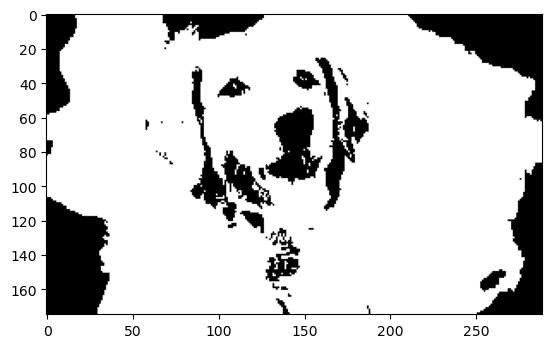

In [28]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

retval, img_thresh = cv2.threshold(img_gray.copy(), 100, 255, cv2.THRESH_BINARY)

plt.imshow(img_thresh, cmap='gray')
plt.show()

Bitwise Operations (Binary comparision)

cv2.bitwise_and()
cv2.bitwise_or()
cv2.bitwise_xor()
cv2.bitwise_not()

## Camera Access

In [5]:
import cv2

# Open the default camera
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()

    # Display the resulting frame
    cv2.imshow('frame', frame)

    # If the user presses 'q', break the loop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture and close windows
cap.release()
cv2.destroyAllWindows()